In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ilipy import  Session
from ilipy.database import DistanceCorrelation
from rnd.utils.data_utils import (
    set_ili_run,
    extract_arm_angles,
    create_arm_array,
)

In [2]:
run_number = 4
_, _, inspection_id, env, _, start_dist, end_dist = set_ili_run(run_number)
session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PySettings.cpp(46): ilipy: Build 0.17.2.10683 4a51d5977e release-ili-0.17 'Tue Jul 15 01:30:00 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(168): WebSoc

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


[[0.22237127]]
[[0.26490724]
 [0.28638592]
 [0.20504601]
 [0.18291514]
 [0.18133777]
 [0.20007676]
 [0.2215227 ]
 [0.20143586]
 [0.19648048]
 [0.24405965]
 [0.20007119]
 [0.16912255]
 [0.20514408]
 [0.20048021]
 [0.19623086]
 [0.20753588]
 [0.21586898]
 [0.17052189]
 [0.19118151]
 [0.20987986]]
[[1.]]


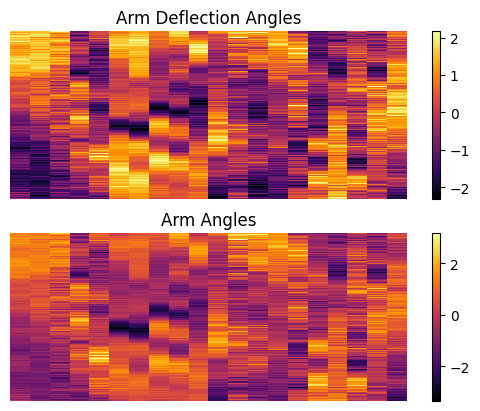

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [67]:
def min_max_normalize(arr):
    arr_min = arr.min(axis=1, keepdims=True)
    arr_max = arr.max(axis=1, keepdims=True)
    denom = np.where((arr_max - arr_min) == 0, 1, arr_max - arr_min)
    return (arr - arr_min) / denom

def z_normalize(arr, axis=None):
    arr_mean = arr.mean(axis=axis, keepdims=True)
    arr_std = arr.std(axis=axis, keepdims=True)
    print(arr_std)
    return (arr - arr_mean) / np.where(arr_std == 0, 1, arr_std)

def moving_average(x, window_size=100):
    return np.convolve(x, np.ones(window_size)/window_size, mode='same')

img_start = 113270.464 -0.25
length = 0.5
img_range = (img_start, img_start + length)
tick_sampling_interval = 10

arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
num_tick_samples = int(length * 10000 / tick_sampling_interval)
img = create_arm_array(arm_angles, num_tick_samples=num_tick_samples, normalize=False)

#img_s = np.apply_along_axis(moving_average, 1, img, window_size=3)
img_norm = min_max_normalize(img)

img_z1 = z_normalize(img_norm)
img_z2 = z_normalize(img_norm, axis=1)
img_z3 = z_normalize(img_z2)

# row_diffs = np.diff(img, axis=0, n=0)
# row_diffs_norm = min_max_normalize(row_diffs)
# row_diffs_z = z_normalize(row_diffs_norm)




plt.subplot(2, 1, 1)
plt.imshow(
    img_z1.T, cmap="inferno", origin="lower", aspect="auto",
    interpolation="nearest",
)
plt.axis("off")
plt.colorbar()
plt.title("Arm Deflection Angles")

plt.subplot(2, 1, 2)
plt.imshow(
    img_z3.T, cmap="inferno", origin="lower", aspect="auto",
    interpolation="nearest",
)
plt.axis("off")
plt.colorbar()
plt.title("Arm Angles")
plt.show()
plt.close()

